In [5]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


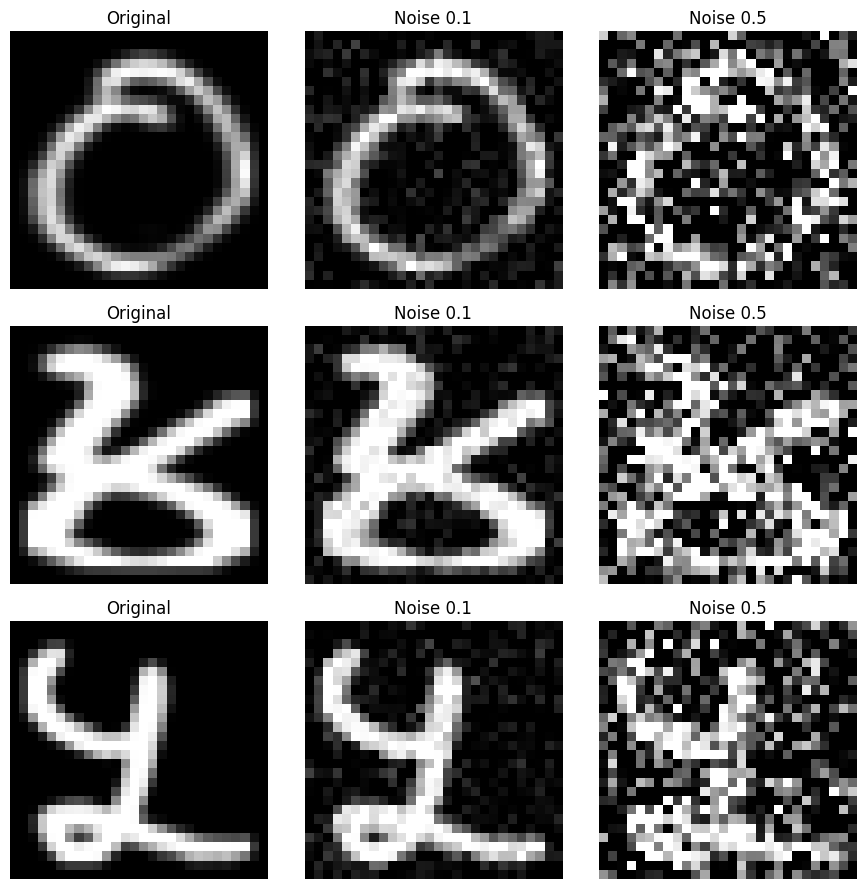

In [6]:
# Dataset paths
base_dir = '/content/drive/MyDrive/AI and ML/Week4/devnagari_digits/DevanagariHandwrittenDigitDataset'
train_dir = os.path.join(base_dir, 'Train')
test_dir = os.path.join(base_dir, 'Test')

# Image dimensions
img_height, img_width = 28, 28


def load_images_only(folder):
    """
    Load grayscale images from class subfolders, resize them,
    normalize pixel values to [0, 1], and return as a NumPy array.
    """
    images = []
    class_names = sorted(os.listdir(folder))  # Ensures consistent class order

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            img = Image.open(img_path).convert("L")   # Convert to grayscale
            img = img.resize((img_width, img_height))
            img = np.array(img) / 255.0              # Normalize pixel values

            images.append(img)

    return np.array(images)


# Load training and testing images
x_train = load_images_only(train_dir)
x_test = load_images_only(test_dir)

# Reshape for CNN input: (samples, height, width, channels)
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)


# Noise levels for denoising experiments
noise_factor_low = 0.1
noise_factor_high = 0.5

# Add Gaussian noise
x_train_noisy_low = x_train + noise_factor_low * np.random.normal(0.0, 1.0, x_train.shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(0.0, 1.0, x_train.shape)

x_test_noisy_low = x_test + noise_factor_low * np.random.normal(0.0, 1.0, x_test.shape)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(0.0, 1.0, x_test.shape)

# Keep pixel values within valid range
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)


# Visualize original vs noisy samples
n = 3
random_indices = np.random.choice(len(x_train), n, replace=False)

plt.figure(figsize=(9, 9))

for i, idx in enumerate(random_indices):

    # Original image
    plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train[idx].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Low-noise image
    plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low[idx].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.1")
    plt.axis('off')

    # High-noise image
    plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high[idx].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.5")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


def build_encoder(input_shape=(28, 28, 1)):
    """
    Constructs the encoder section of the convolutional autoencoder.

    This part compresses the input image into a lower-dimensional
    feature representation by applying convolutional layers to extract
    patterns and max-pooling layers to reduce spatial dimensions.

    Parameters:
        input_shape (tuple): Dimensions of the input grayscale image.
                             Default is (28, 28, 1).

    Returns:
        input_img: Input layer for the encoder.
        encoded: Compressed feature representation of the image.
    """

    # Input layer for grayscale digit images
    input_img = Input(shape=input_shape, name="input")

    # Extract low-level image features
    x = Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
    x = MaxPooling2D((2, 2), padding="same")(x)

    # Learn deeper feature representations
    x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)

    # Final compressed latent representation
    encoded = MaxPooling2D((2, 2), padding="same", name="encoded")(x)

    return input_img, encoded

In [8]:
def build_decoder(encoded_input):
    """
    Constructs the decoder section of the convolutional autoencoder.

    This part reconstructs the compressed feature representation
    back into the original image dimensions using convolution
    and upsampling layers.

    Parameters:
        encoded_input: Compressed latent representation from the encoder.

    Returns:
        decoded: Reconstructed output image.
    """

    # Reconstruct high-level features
    x = Conv2D(64, (3, 3), activation="relu", padding="same")(encoded_input)
    x = UpSampling2D((2, 2))(x)

    # Refine spatial details
    x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = UpSampling2D((2, 2))(x)

    # Output reconstructed grayscale image
    decoded = Conv2D(1,(3, 3), activation="sigmoid", padding="same", name="decoded")(x)

    return decoded

In [9]:
def build_autoencoder():
    """
    Constructs and compiles the full convolutional autoencoder by connecting encoder and
    decoder.
    Returns:
    autoencoder (Keras Model): Compiled autoencoder model.
    """
    input_img, encoded_output = build_encoder()
    decoded_output = build_decoder(encoded_output)
    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
    autoencoder.compile(optimizer=Adam(), loss="binary_crossentropy")
    return autoencoder

In [10]:
# Build the complete autoencoder model and display its architecture
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Build the complete autoencoder model
autoencoder = build_autoencoder()

# Train the model to reconstruct clean images from noisy inputs
history = autoencoder.fit(
    x_train_noisy_high,   # Noisy training images
    x_train,              # Original clean target images
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 57s 408ms/step - loss: 0.3124 - val_loss: 0.2174
Epoch 2/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 80s 400ms/step - loss: 0.2101 - val_loss: 0.2028
Epoch 3/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 51s 385ms/step - loss: 0.2010 - val_loss: 0.1972
Epoch 4/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 53s 401ms/step - loss: 0.1958 - val_loss: 0.1933
Epoch 5/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 79s 382ms/step - loss: 0.1930 - val_loss: 0.1915
Epoch 6/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 54s 409ms/step - loss: 0.1908 - val_loss: 0.1893
Epoch 7/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 79s 383ms/step - loss: 0.1891 - val_loss: 0.1877
Epoch 8/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 83s 391ms/step - loss: 0.1880 - val_loss: 0.1867
Epoch 9/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 54s 408ms/step - loss: 0.1868 - val_loss: 0.1856
Epoch 10/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 79s 384ms/step - loss: 0.1857 - val_loss: 0.1854


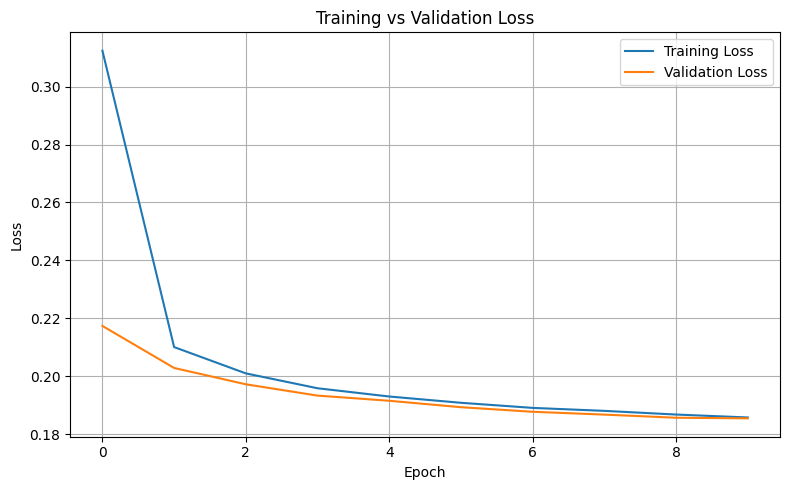

In [12]:
import matplotlib.pyplot as plt

# Visualize training and validation loss across epochs
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


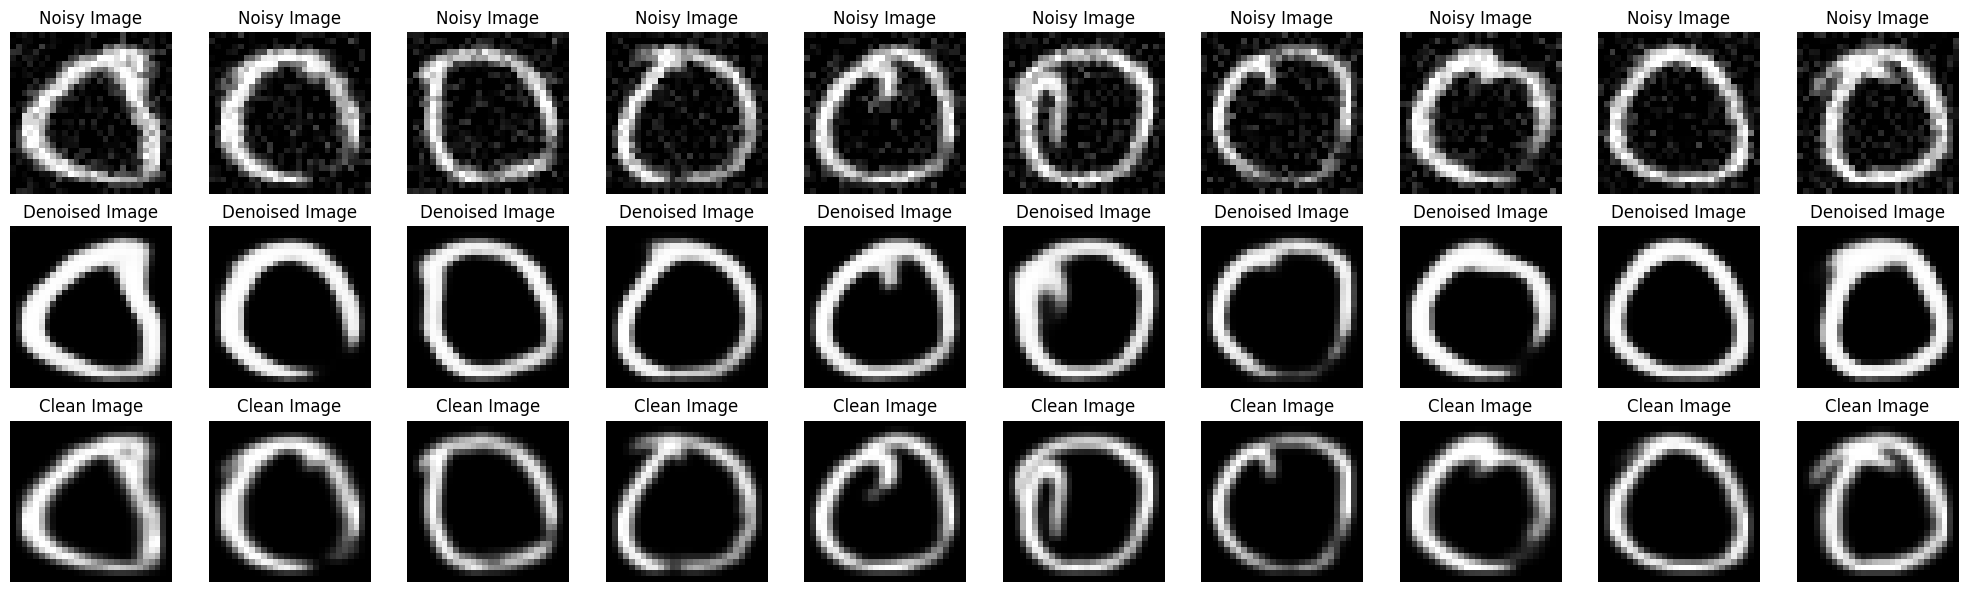

In [13]:
# Generate denoised outputs from noisy test images
denoised_images = autoencoder.predict(x_test_noisy_low)


def plot_images(noisy_images, denoised_images, clean_images, n=10):
    """
    Displays noisy, denoised, and clean images for comparison.

    Parameters:
        noisy_images: Input images with added noise.
        denoised_images: Images reconstructed by the autoencoder.
        clean_images: Original ground-truth images.
        n (int): Number of samples to display.
    """

    plt.figure(figsize=(20, 6))

    for i in range(n):

        # Top row: noisy input images
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy Image")
        plt.axis('off')

        # Middle row: autoencoder output
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised Image")
        plt.axis('off')

        # Bottom row: original clean reference
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.title("Clean Image")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


# Display sample reconstruction results
plot_images(x_test_noisy_low, denoised_images, x_test, n=10)